In [400]:
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import matplotlib.dates as mdates

# 1. Process & Explore data

In [401]:
# We need to extract the times from the data files 
# and create a matrix using (O,D) pairs with times
tt1 = pd.read_csv('travel_times_15_17.csv')
tt2 = pd.read_csv('travel_times_17_19.csv')
tt3 = pd.read_csv('travel_times_19_21.csv')
tt1.head()

,departure_time,origin_station_id,origin_name,origin_lat,origin_lon,dest_station_id,dest_name,dest_lat,dest_lon,distance_meters,duration_seconds,duration_minutes,duration_in_traffic_seconds,duration_in_traffic_minutes,status
0,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8589152,"Fribourg, Mon-Repos",46.806711,7.172136,270,35,0.58,42,0.70,OK
1,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8589138,"Fribourg, Cité-Jardins",46.809385,7.170446,659,86,1.43,117,1.95,OK
2,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8591766,"Fribourg, Boschung",46.811451,7.171016,1013,138,2.30,174,2.90,OK
3,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8587255,"Fribourg, Tilleul/Cathédrale",46.806090,7.161261,3788,445,7.42,506,8.43,OK
4,2026-02-12 15:00:00,8589141,"Fribourg, Chaley",46.806281,7.175601,8589161,"Fribourg, St-Pierre",46.803911,7.155266,4335,561,9.35,622,10.37,OK


* Number of trips

In [402]:
shape1 = tt1.shape[0]
shape2 = tt2.shape[0]
shape3 = tt3.shape[0]

print("Number of trips between 15-17: ",shape1)
print("Number of trips between 17-19: ",shape2)
print("Number of trips between 19-21: ",shape3)

Number of trips between 15-17:  5684
Number of trips between 17-19:  10556
Number of trips between 19-21:  5684


In [403]:
time_window = 15

# Combine them into a single DataFrame
df_all = pd.concat([tt1, tt2, tt3], ignore_index=True)

# Convert departure_time to datetime objects for accurate time manipulation
df_all['departure_time'] = pd.to_datetime(df_all['departure_time'])

# 2. Extract just the hour and minute to make filtering date-independent
df_all['hour'] = df_all['departure_time'].dt.hour
df_all['minute'] = df_all['departure_time'].dt.minute

# 4. Full breakdown of all 15-minute bins to see where the data actually sits
# We floor the time to the nearest 15 minutes, then extract just the time component
df_all['time_bin'] = df_all['departure_time'].dt.floor(f'{time_window}min').dt.time

# Count the occurrences and sort chronologically (15:00 through 20:45)
full_breakdown = df_all['time_bin'].value_counts().sort_index()

print("Breakdown by 15-minute bins (15:00 to 21:00):")
print(full_breakdown[:10])
print("-" * 40)

# 5. AUTOMATIC EMPTY BIN DETECTION
# Generate a perfect list of what the bins *should* be
expected_bins = pd.date_range("15:00", "20:45", freq="15min").time

# Find which expected bins are missing from our actual data's index
missing_bins = [b for b in expected_bins if b not in full_breakdown.index]

if missing_bins:
    print("The following 15-minute bins are completely empty (0 requests):")
    for b in missing_bins:
        print(f" - {b.strftime('%H:%M')}")
else:
    print("No missing 15-minute bins found in the 6-hour window! Data is continuous.")
print("-" * 40)

Breakdown by 15-minute bins (15:00 to 21:00):
time_bin
15:00:00     812
15:15:00     812
15:30:00     812
16:00:00     812
16:15:00     812
16:30:00     812
17:00:00    2436
17:15:00     812
17:30:00    1624
17:45:00     812
Name: count, dtype: int64
----------------------------------------
The following 15-minute bins are completely empty (0 requests):
 - 15:45
 - 16:45
 - 19:45
 - 20:45
----------------------------------------


* Histogram distance vs distance in traffic

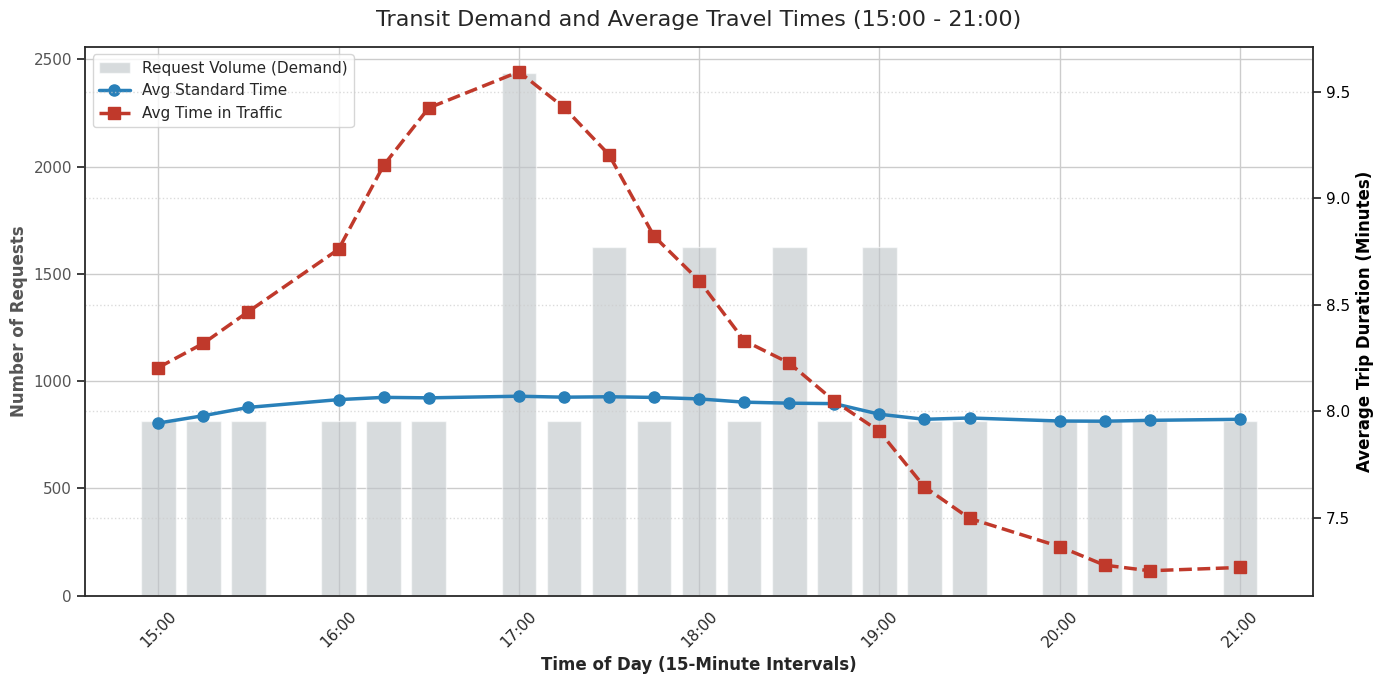

In [404]:
# 1. Convert the strings to datetime objects FIRST
df_all['departure_time'] = pd.to_datetime(df_all['departure_time'])

# 2. Group the data into 15-minute bins
# This aggregates thousands of rows into clean, readable intervals
# 2. NOW you can group the data into 15-minute bins
df_all['time_bin'] = df_all['departure_time'].dt.floor(f'{time_window}min')

# Calculate the mean times and the total count of requests per bin
agg_df = df_all.groupby('time_bin').agg(
    request_volume=('duration_minutes', 'count'),
    avg_std_time=('duration_minutes', 'mean'),
    avg_trf_time=('duration_in_traffic_minutes', 'mean')
).reset_index()

# 3. Create the Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(14, 7))
sns.set_theme(style="white")

# --- AXIS 1: Bar Plot for Request Volume ---
color_bars = '#bdc3c7' # Light gray so it doesn't overpower the lines
ax1.bar(agg_df['time_bin'], agg_df['request_volume'], width=0.008, 
        color=color_bars, alpha=0.6, label='Request Volume (Demand)')

ax1.set_xlabel('Time of Day (15-Minute Intervals)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Requests', color='#555555', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#555555')

# Format the x-axis to show HH:MM nicely
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)

# --- AXIS 2: Line Plot for Travel Times ---
# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()  

color_std = '#2980b9' # Strong Blue
color_trf = '#c0392b' # Strong Red

ax2.plot(agg_df['time_bin'], agg_df['avg_std_time'], color=color_std, 
         marker='o', linewidth=2.5, markersize=8, label='Avg Standard Time')
ax2.plot(agg_df['time_bin'], agg_df['avg_trf_time'], color=color_trf, 
         marker='s', linewidth=2.5, markersize=8, linestyle='--', label='Avg Time in Traffic')

ax2.set_ylabel('Average Trip Duration (Minutes)', color='black', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')

# --- Styling and Legends ---
plt.title('Transit Demand and Average Travel Times (15:00 - 21:00)', fontsize=16, pad=15)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, facecolor='white')

# Add a subtle grid to the background based on the time axis
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [405]:
# --- 2. STATISTICAL SUMMARY ---
def calculate_summary_stats(df):
    cols = ['duration_minutes', 'duration_in_traffic_minutes']
    
    # Calculate key metrics
    summary = pd.DataFrame({
        'Mean': df[cols].mean(),
        'Median': df[cols].median(),
        'Std Dev': df[cols].std(),
        'Std Error': df[cols].sem(),
        'Min': df[cols].min(),
        'Max': df[cols].max()
    }).transpose()
    
    # Calculate Traffic Impact Factor
    avg_delay = ((df['duration_in_traffic_minutes'].mean() - df['duration_minutes'].mean()) 
                 / df['duration_minutes'].mean()) * 100
    
    print("-" * 50)
    print("      STATISTICAL SUMMARY ")
    print("-" * 50)
    print(summary.round(3))
    print("-" * 50)
    print(f"Average Traffic Delay Factor: {avg_delay:.2f}%")
    print("-" * 50)

In [406]:
calculate_summary_stats(tt1)
calculate_summary_stats(tt2)
calculate_summary_stats(tt3)

--------------------------------------------------
      STATISTICAL SUMMARY 
--------------------------------------------------
           duration_minutes  duration_in_traffic_minutes
Mean                  8.029                        8.849
Median                8.300                        9.310
Std Dev               3.956                        4.339
Std Error             0.052                        0.058
Min                   0.200                        0.220
Max                  18.370                       18.780
--------------------------------------------------
Average Traffic Delay Factor: 10.22%
--------------------------------------------------
--------------------------------------------------
      STATISTICAL SUMMARY 
--------------------------------------------------
           duration_minutes  duration_in_traffic_minutes
Mean                  8.051                        8.755
Median                8.330                        9.250
Std Dev               3.960      

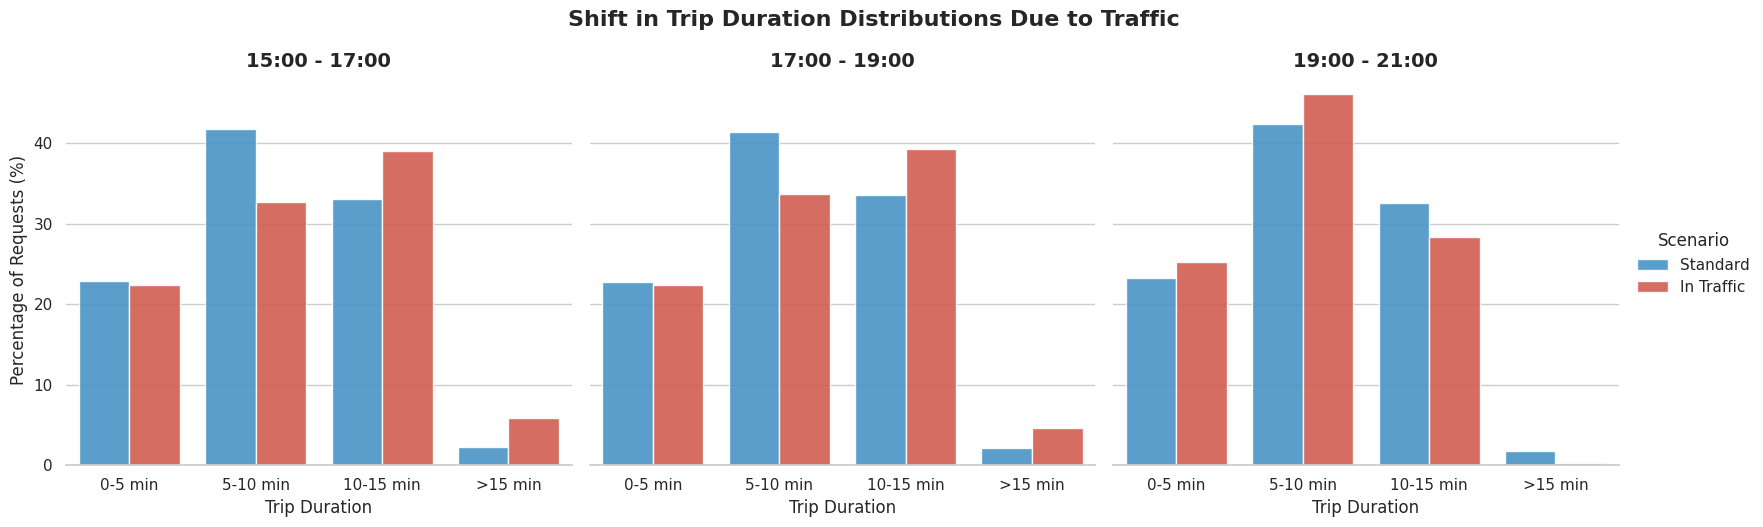

In [407]:
# Assuming tt1, tt2, tt3 are already loaded in your environment
datasets = [
    (tt1, '15:00 - 17:00'), 
    (tt2, '17:00 - 19:00'), 
    (tt3, '19:00 - 21:00')
]

plot_data = []

# 1. Process and Bin the data for all three DataFrames
for df, time_label in datasets:
    # Define bins
    max_val = max(df['duration_minutes'].max(), df['duration_in_traffic_minutes'].max()) + 1
    bins = [0, 5, 10, 15, max_val]
    bin_labels = ['0-5 min', '5-10 min', '10-15 min', '>15 min']
    
    # Categorize durations into bins
    std_bins = pd.cut(df['duration_minutes'], bins=bins, labels=bin_labels, right=False)
    trf_bins = pd.cut(df['duration_in_traffic_minutes'], bins=bins, labels=bin_labels, right=False)
    
    # Calculate percentages
    std_pct = std_bins.value_counts(normalize=True).sort_index() * 100
    trf_pct = trf_bins.value_counts(normalize=True).sort_index() * 100
    
    # Append to our plotting list
    for b in bin_labels:
        plot_data.append({'Time Window': time_label, 'Condition': 'Standard', 'Bin': b, 'Percentage': std_pct.get(b, 0)})
        plot_data.append({'Time Window': time_label, 'Condition': 'In Traffic', 'Bin': b, 'Percentage': trf_pct.get(b, 0)})

# Convert to a DataFrame optimized for Seaborn
df_plot = pd.DataFrame(plot_data)

# 2. Create the Visualization
sns.set_theme(style="whitegrid")

# Create a multi-panel bar chart (catplot)
g = sns.catplot(
    data=df_plot, kind="bar",
    x="Bin", y="Percentage", hue="Condition", col="Time Window",
    palette=["#3498db", "#e74c3c"], # Blue for Standard, Red for Traffic
    height=5, aspect=1.1, alpha=0.9
)

# Formatting
g.despine(left=True)
g.set_axis_labels("Trip Duration", "Percentage of Requests (%)")
g.set_titles("{col_name}", size=14, weight='bold') # Set subplot titles
g.legend.set_title("Scenario")

# Add a main title
plt.suptitle("Shift in Trip Duration Distributions Due to Traffic", y=1.05, fontsize=16, weight='bold')

plt.show()

* Distances

In [408]:
def calculate_distance_stats(df, time_window):
    # Calculate distances in km directly from the column
    dist_km = df['distance_meters'] / 1000.0
    
    # Calculate key statistics
    distance_summary = pd.DataFrame({
        'Mean (km)': [dist_km.mean()],
        'Median (km)': [dist_km.median()],
        'Std Dev (km)': [dist_km.std()],
        'Min (km)': [dist_km.min()],
        'Max (km)': [dist_km.max()]
    }).transpose()

    # Print formatted output
    print("-" * 35)
    print(f"   DISTANCE STATISTICS ({time_window})")
    print("-" * 35)
    print(distance_summary.round(2))
    print("-" * 35)
    print() # Adds a blank line for readability between tables

# Assuming tt1, tt2, and tt3 are already loaded in your notebook:
calculate_distance_stats(tt1, "15:00 - 17:00")
calculate_distance_stats(tt2, "17:00 - 19:00")
calculate_distance_stats(tt3, "19:00 - 21:00")

-----------------------------------
   DISTANCE STATISTICS (15:00 - 17:00)
-----------------------------------
                  0
Mean (km)      3.94
Median (km)    3.56
Std Dev (km)   2.66
Min (km)       0.08
Max (km)      10.05
-----------------------------------

-----------------------------------
   DISTANCE STATISTICS (17:00 - 19:00)
-----------------------------------
                 0
Mean (km)     3.98
Median (km)   3.61
Std Dev (km)  2.68
Min (km)      0.08
Max (km)      9.80
-----------------------------------

-----------------------------------
   DISTANCE STATISTICS (19:00 - 21:00)
-----------------------------------
                 0
Mean (km)     3.83
Median (km)   3.46
Std Dev (km)  2.55
Min (km)      0.08
Max (km)      9.80
-----------------------------------



* Set with origins and set with destinations from data above

In [409]:
destinations = tt1['dest_name']
origins = tt1['origin_name']
print("Number of destinations: ", len(destinations.unique()))
print(destinations.unique()[:10])
print("Number of origins: ", len(origins.unique()))
print(origins.unique()[:10])

Number of destinations:  29
<StringArray>
[           'Fribourg, Mon-Repos',         'Fribourg, Cité-Jardins',
             'Fribourg, Boschung',   'Fribourg, Tilleul/Cathédrale',
            'Fribourg, St-Pierre',    'Fribourg/Freiburg, Pl. Gare',
  'Villars-sur-Glâne, Méridienne',      'Villars-sur-Glâne, Moncor',
 'Villars-sur-Glâne, Belle-Croix',               'Fribourg, Chaley']
Length: 10, dtype: str
Number of origins:  29
<StringArray>
[              'Fribourg, Chaley',            'Fribourg, Mon-Repos',
         'Fribourg, Cité-Jardins',             'Fribourg, Boschung',
   'Fribourg, Tilleul/Cathédrale',            'Fribourg, St-Pierre',
    'Fribourg/Freiburg, Pl. Gare',  'Villars-sur-Glâne, Méridienne',
      'Villars-sur-Glâne, Moncor', 'Villars-sur-Glâne, Belle-Croix']
Length: 10, dtype: str


In [410]:
tt1_copy = tt1.copy()

# Load Data
tt1 = pd.read_csv('travel_times_15_17.csv')
tt1['departure_time'] = pd.to_datetime(tt1['departure_time'])


# Create explicit ID columns in your base DataFrame
tt1_copy['p_id'] = tt1_copy.index  # Pickup Node 1 to n
tt1_copy['d_id'] = tt1_copy.index + len(tt1_copy)  # Dropoff Node n+1 to 2n

# Number of requests (n)
n = len(tt1_copy)

* Matrix with (O,D) pairs: time I think (distance maybe?)
* MILP only optimize every x minutes so only take x minutes

In [411]:
# 2. Build Travel Matrix (Dictionary for O(1) lookups)
travel_matrix = {}
for _, row in tt1.iterrows():
    travel_matrix[(row['origin_station_id'], row['dest_station_id'])] = row['duration_in_traffic_minutes']

all_stations = set(tt1['origin_station_id']).union(set(tt1['dest_station_id']))
for s in all_stations:
    travel_matrix[(s, s)] = 0.0

# 2. Define parameters

In [412]:
# 1. Define Fleet (3 types, 11 buses total)
# Type 4: 5 buses | Type 6: 4 buses | Type 8: 2 buses
n1 = 20
n2 = 6
n3 = 1
bus_capacities = [4]*n1 + [6]*n2 + [8]*n3
bus_costs = [20]*n1 + [50]*n2 + [70]*n3  # Cost per minute
buses = range(len(bus_capacities))

# 2. Project Parameters
PARAMS = {
    'b1': 1,
    'b2': 1,
    'b3': 1,
    'time_window': 15,
    'max_req_per_window': 15, # STAY UNDER 2000 VARIABLES
    'buses': [0, 1, 2, 3],
    'bus_capacity': bus_capacities, # 4 buses of varying sizes
    'cost_per_bus': bus_costs,
    'cost_reject': 200,
    'si': 2,                 # Service time to board/alight
    'max_transfer_time': 10, # Prune arcs: Don't drive >10 mins empty
    'max_ride_time': 25,     # L_i: Max time a passenger stays in bus
    'M_time': 60,            # Big-M for time (tightened for speed)
    'M_load': 10             # Big-M for load (tightened for speed)
}

* Number of passenger: Poisson distribution

In [413]:
# Let's add the number of passenger as a list of random values
vehicules = np.zeros(tt1.shape[0])
print("Number of trips: ",tt1.shape[0])

# Always get same random values
np.random.seed(42)

# Poisson distribution around (usually most people) and maximum value of people is 8
passengers = np.random.poisson(lam=3, size=tt1.shape[0])
passengers = np.clip(passengers, 1, 6)

# Helper function: I need to look at what vehicule each group actually need to be assigned to:
for i, pax in enumerate(passengers):
    for cap in bus_capacities:
        if pax <= cap:
            vehicules[i] = cap
            break # stop at the first bus that fits

print(passengers[:20])
print("Mean number of passengers per vehicule: ",np.mean(passengers))
print(vehicules[:20])
print("Mean vehicule size: ", np.mean(vehicules))

Number of trips:  5684
[4 1 3 3 2 3 2 3 1 2 4 2 1 3 4 4 1 2 3 2]
Mean number of passengers per vehicule:  3.001935256861365
[4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]
Mean vehicule size:  4.363828289936665


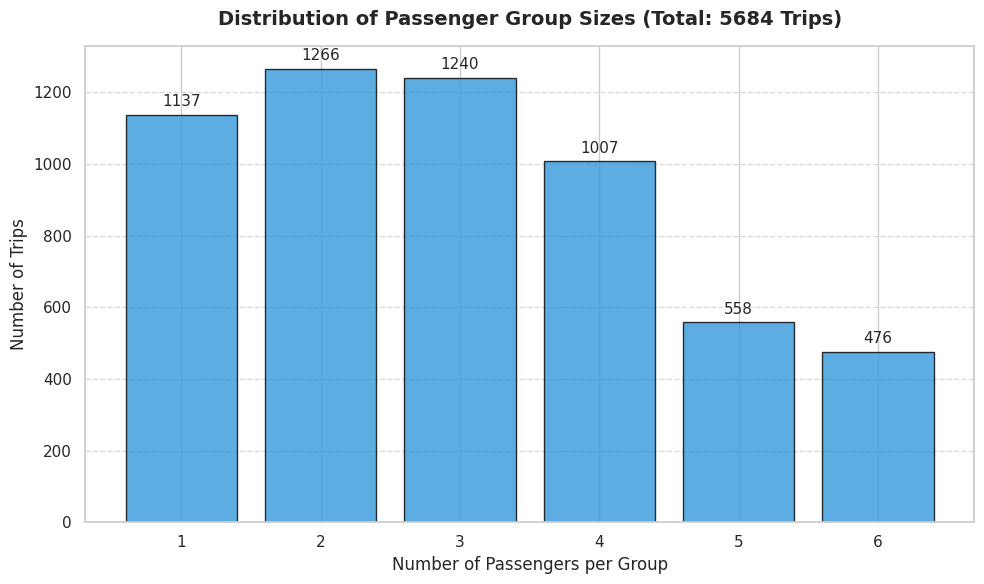

In [414]:
# 2. Count the occurrences of each group size
unique, counts = np.unique(passengers, return_counts=True)

# 3. Create the Bar Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(unique, counts, color='#3498db', edgecolor='black', alpha=0.8)

# 4. Formatting and Labels
ax.set_title('Distribution of Passenger Group Sizes (Total: 5684 Trips)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Passengers per Group', fontsize=12)
ax.set_ylabel('Number of Trips', fontsize=12)
ax.set_xticks(range(1, 7)) # Ensure all ticks from 1 to 8 are shown

# 5. Add exact numbers on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 15, int(yval), ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

* Window

In [415]:
""" start_time = tt1_copy['departure_time'].min().floor('15min')
end_time = tt1_copy['departure_time'].max().ceil('15min')
time_slots = pd.date_range(start=start_time, end=end_time, freq=f'{time_window}min')
 
all_solutions = {}
 
for idx, current_time in enumerate(time_slots[:-1]):
    
    next_time = current_time + pd.Timedelta(minutes=time_window)
    
    print(f"WINDOW {idx+1}/{len(time_slots)-1}: {current_time.strftime('%H:%M')} - {next_time.strftime('%H:%M')}")
    
    # Extract trips in this window
    mask = (tt1_copy['departure_time'] >= current_time) & (tt1_copy['departure_time'] < next_time)
    window_df = tt1_copy[mask].copy()
    
    if len(window_df) == 0:
        print("No trips in this window")
        continue
    
    window_requests = window_df.index.tolist()
    print(f"Requests: {len(window_requests)}")
    
    # Create arcs: all i→j pairs where i,j ∈ nodes, i≠j
    window_arcs = [(i, j) for i in all_nodes for j in all_nodes if i != j]

     """

' start_time = tt1_copy[\'departure_time\'].min().floor(\'15min\')\nend_time = tt1_copy[\'departure_time\'].max().ceil(\'15min\')\ntime_slots = pd.date_range(start=start_time, end=end_time, freq=f\'{time_window}min\')\n\nall_solutions = {}\n\nfor idx, current_time in enumerate(time_slots[:-1]):\n\n    next_time = current_time + pd.Timedelta(minutes=time_window)\n\n    print(f"WINDOW {idx+1}/{len(time_slots)-1}: {current_time.strftime(\'%H:%M\')} - {next_time.strftime(\'%H:%M\')}")\n\n    # Extract trips in this window\n    mask = (tt1_copy[\'departure_time\'] >= current_time) & (tt1_copy[\'departure_time\'] < next_time)\n    window_df = tt1_copy[mask].copy()\n\n    if len(window_df) == 0:\n        print("No trips in this window")\n        continue\n\n    window_requests = window_df.index.tolist()\n    print(f"Requests: {len(window_requests)}")\n\n    # Create arcs: all i→j pairs where i,j ∈ nodes, i≠j\n    window_arcs = [(i, j) for i in all_nodes for j in all_nodes if i != j]\n\n     '

# 3. Model definition

* Create create window and loop throught window

In [416]:
def optimize_assignment_window(window_df, window_passengers, capacities, costs, params, time_label):
    """
    Assigns groups to buses. 1 Group per bus. No pooling.
    Includes Variable Pruning to respect Gurobi Free License limits.
    """
    m = gp.Model(f"Assignment_{time_label}")
    m.setParam('OutputFlag', 0)

    requests = window_df.index.tolist()
    buses = range(len(capacities))

    # --- VARIABLE PRUNING ---
    x = {}
    for r in requests:
        group_size = window_passengers[r]
        for k in buses:
            if group_size <= capacities[k]:
                # Only add variable if assignment is physically possible
                x[r, k] = m.addVar(vtype=GRB.BINARY, name=f"x_{r}_{k}")

    # --- OBJECTIVE ---
    obj_op = gp.quicksum(
        costs[k] * window_df.loc[r, 'duration_in_traffic_minutes'] * x[r, k]
        for (r, k) in x.keys()
    )

    obj_reject = params['cost_reject'] * gp.quicksum(
        1 - gp.quicksum(x[r, k] for k in buses if (r, k) in x) 
        for r in requests
    )

    m.setObjective(params['b1'] * obj_op + params['b2'] * obj_reject, GRB.MINIMIZE)

    # --- CONSTRAINTS ---
    for r in requests:
        valid_buses_for_req = [x[r, k] for k in buses if (r, k) in x]
        if valid_buses_for_req:
            m.addConstr(gp.quicksum(valid_buses_for_req) <= 1)

    for k in buses:
        valid_reqs_for_bus = [x[r, k] for r in requests if (r, k) in x]
        if valid_reqs_for_bus:
            m.addConstr(gp.quicksum(valid_reqs_for_bus) <= 1)

    m.optimize()

    # --- EXTRACT THE ACTUAL USED CAPACITIES ---
    if m.status == GRB.OPTIMAL:
        served = 0
        used_capacities = []
        served_group_sizes = []
        
        # Loop through all valid combinations
        for (r, k), var in x.items():
            if var.X > 0.5:  # If Gurobi set this binary variable to 1
                served += 1
                used_capacities.append(capacities[k])
                served_group_sizes.append(window_passengers[r])
                
        return {
            "status": "Optimal", 
            "served": served, 
            "total": len(requests), 
            "obj": m.ObjVal,
            "used_caps": used_capacities,           
            "served_groups": served_group_sizes     
        }
        
    return {"status": "No Solution", "served": 0, "total": len(requests), "obj": 0, "used_caps": [], "served_groups": []}

In [417]:

# Force conversion again just to be safe
tt1['departure_time'] = pd.to_datetime(tt1['departure_time'])

time_slots = pd.date_range(
    start=tt1['departure_time'].min().floor(f"{PARAMS['time_window']}min"), 
    end=tt1['departure_time'].max().ceil(f"{PARAMS['time_window']}min"), 
    freq=f"{PARAMS['time_window']}min"
)

print(f"Fleet: {len(bus_capacities)} buses available.")
print("-" * 50)

# --- 1. INITIALIZE LISTS TO STORE DATA ---
results_data = []
all_used_caps = []
all_served_groups = []

for current_time in time_slots[:-1]:
    next_time = current_time + pd.Timedelta(minutes=PARAMS['time_window'])
    
    mask = (tt1['departure_time'] >= current_time) & (tt1['departure_time'] < next_time)
    window_df = tt1[mask].copy()
    
    if window_df.empty: continue
        
    # --- STAY UNDER GUROBI LIMITS --- 
    limit = 50
    if len(window_df) > limit:
        window_df = window_df.head(limit) # Cap at 100 requests per window
        
    window_pax = {idx: passengers[idx] for idx in window_df.index}
    time_str = current_time.strftime('%H:%M')
    
    result = optimize_assignment_window(window_df, window_pax, bus_capacities, bus_costs, PARAMS, time_str)
    
    # --- GET THE EXACT CAPACITIES USED IN THIS WINDOW ---
    current_used_caps = result.get('used_caps', [])
    
    # Count how many of each type were dispatched
    used_4 = current_used_caps.count(4)
    used_6 = current_used_caps.count(6)
    used_8 = current_used_caps.count(8)
    
    # --- 2. SAVE THE RESULTS ---
    results_data.append({
        'Time': time_str,
        'Total Requests': result['total'],
        'Served': result['served'],
        'Missed': result['total'] - result['served'], 
        'Score': result['obj'],
        '4-Seaters Used': used_4, 
        '6-Seaters Used': used_6,  
        '8-Seaters Used': used_8   
    })
    
    # Aggregate the capacity data for the whole day
    all_used_caps.extend(current_used_caps)
    all_served_groups.extend(result.get('served_groups', []))
    
    # Print the breakdown so you can see it live!
    print(f"[{time_str}] Requests: {result['total']:02d} | Served: {result['served']:02d} | "
          f"Buses -> [4-seat: {used_4}, 6-seat: {used_6}, 8-seat: {used_8}] | Score: {result['obj']:.2f}")

Fleet: 27 buses available.
--------------------------------------------------
[15:00] Requests: 50 | Served: 25 | Buses -> [4-seat: 20, 6-seat: 5, 8-seat: 0] | Score: 7105.70
[15:15] Requests: 50 | Served: 26 | Buses -> [4-seat: 20, 6-seat: 6, 8-seat: 0] | Score: 7179.30
[15:30] Requests: 50 | Served: 26 | Buses -> [4-seat: 20, 6-seat: 6, 8-seat: 0] | Score: 7185.60
[16:00] Requests: 50 | Served: 24 | Buses -> [4-seat: 20, 6-seat: 4, 8-seat: 0] | Score: 7257.30
[16:15] Requests: 50 | Served: 23 | Buses -> [4-seat: 20, 6-seat: 3, 8-seat: 0] | Score: 7226.20
[16:30] Requests: 50 | Served: 25 | Buses -> [4-seat: 20, 6-seat: 5, 8-seat: 0] | Score: 7368.70


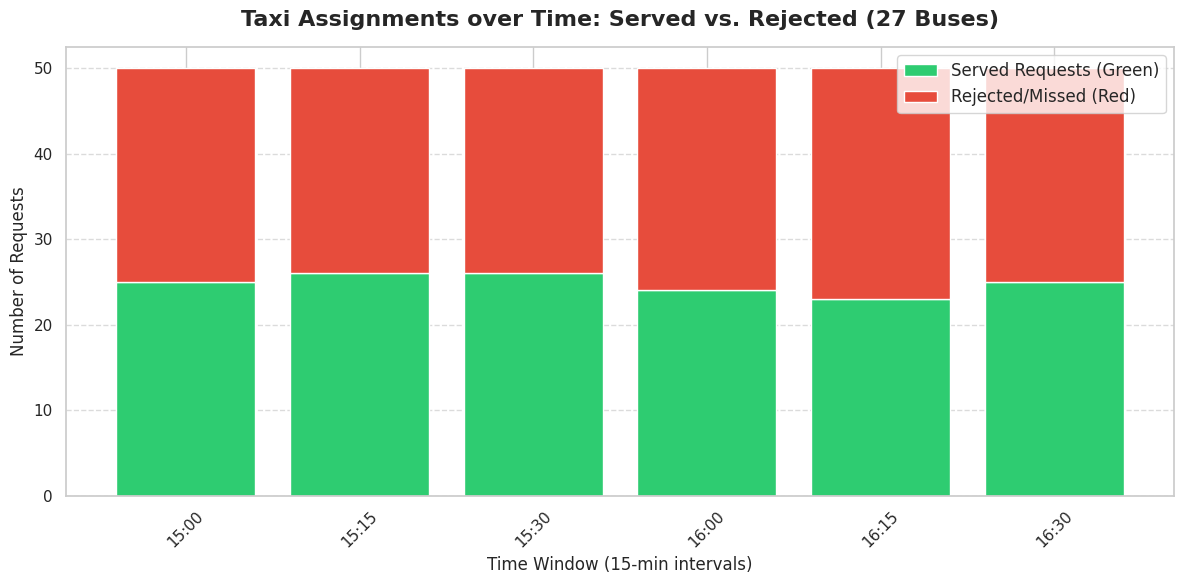

In [418]:
# --- 3. CREATE THE PLOT ---
df_plot = pd.DataFrame(results_data)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot Served (Green) and Missed (Red) stacked on top of each other
ax.bar(df_plot['Time'], df_plot['Served'], label='Served Requests (Green)', color='#2ecc71')
ax.bar(df_plot['Time'], df_plot['Missed'], bottom=df_plot['Served'], label='Rejected/Missed (Red)', color='#e74c3c')

# Formatting
ax.set_title(f'Taxi Assignments over Time: Served vs. Rejected ({len(bus_capacities)} Buses)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Time Window (15-min intervals)', fontsize=12)
ax.set_ylabel('Number of Requests', fontsize=12)
ax.legend(fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()